# 四箱实验：短窗口 Streaming Flow Policy

**版本：v1.0 · 独立 notebook · 从全局最短示范学习局部未来轨迹**

直接在现有 SFP 的 Python / PyTorch 环境里打开，按顺序运行所有单元格。只依赖 `numpy`、`torch`、`matplotlib` 和 Python 标准库，不依赖原项目源码或旧 checkpoint。输出目录默认是当前工作目录下的 `sfp_four_targets_streaming_v1`，第二个代码单元格会打印完整路径。

| 默认设置 | 数值 / 含义 |
|---|---|
| 布局 | 训练 10,000；验证 1,000；测试 1,000 |
| 训练预算 | 1,000 epochs × 100 optimizer steps；batch size 1,024；seed 0 |
| 观测 / 窗口 | 2 帧历史；16 帧总窗口；当前时刻之后 14 个控制间隔 |
| 执行 | 每个 chunk 8 个动作，积分到局部时间 8/14 后重置 |
| 对照 | 同一个模型测试 chunk = 1、4、8、14 |
| 条件 | 最近观测中的实际位置、四箱坐标、实际 visited mask |
| 示范 / 采样 | 每个布局一条全局中心最短路线；训练 Gaussian tube；推理不加噪声 |
| 任务 | 固定起点，四个静止目标，无障碍，不返回起点 |

这是 **SFP 的短窗口训练与流式执行结构在四箱任务上的实现**，不是官方机器人环境或网络架构的逐项复刻。这里采用理想二维位置跟踪：生成一个位置指令，环境马上执行相应直线段；不模拟惯性、控制器滞后或真实机器人的实时并发。超参数是第一版的起始配置，尚未做性能调参。

- 如果只想先确认自己电脑能运行，把 `QUICK_CHECK = True`；它会使用独立缓存和很小的训练预算。正式训练改回 `False`，重新从头运行。
- 继续已有训练：保持设置和输出目录一致，提高 `EPOCHS`，重新运行。它会读取 `latest.pt`。
- 换电脑：复制完整输出文件夹，设置新的 `OUTPUT_DIR`。设备、路径、Python/PyTorch 版本不参与实验身份校验；模型、数据和关键设置参与校验。
- 第一版没有外部路线选择器、推理时最短路求解、未命中后吸附到目标或恢复数据增强。访问状态不会告诉模型下一站。

方法来源：[Streaming Flow Policy, §3–5 / Algorithm 2](https://arxiv.org/html/2505.21851v2)。四箱布局、显式 visited mask、MLP、控制步尺度和评估指标是本实验的具体设计。

## 1. 导入依赖

选择你已经可以运行 PyTorch / CUDA 的 Python 解释器。若这里提示缺少 PyTorch，先检查 notebook 的 kernel 是否选择了原来的 SFP 环境。

In [1]:
from pathlib import Path
import csv
import hashlib
import itertools
import json
import math
import os
import platform
import time
import zipfile

import numpy as np
import matplotlib.pyplot as plt
try:
    import torch
    from torch import nn
except ImportError as exc:
    raise ImportError("Select your existing Python environment with PyTorch installed.") from exc

IMPLEMENTATION = "four_targets_streaming_v1.0"


## 2. 实验设置

一般只需要决定 `OUTPUT_DIR`、`EPOCHS` 和 `SEEDS`。默认使用 GPU（如果当前解释器支持 CUDA）；否则会在 CPU 上运行。

本 notebook 明确定义 `pred_horizon` 为窗口的**总帧数**。当 anchor 为第 $n$ 步时：

- 历史是 $o_{n-1},o_n$；窗口覆盖第 $n-1$ 到 $n+14$ 帧，一共 16 帧。
- $\xi_n(0)=q_n$，$\xi_n(1)=q_{n+14}$，因此 $\Delta\tau=1/14$。
- chunk = 8 时实际执行 $q_{n+1}$ 至 $q_{n+8}$，随后从真实 $q_{n+8}$ 开始下一个窗口。

每个控制步有相同的时间长度；专家相邻位置的间距不超过 0.01。`sigma0=0.02` 是局部窗口训练噪声的初始值，`k=2.5`。推理阶段不会在每个 chunk 重加随机位置噪声。

`EPOCHS` 不参与 run ID，因此可以提高预算续训。改变数据或关键训练设置会进入新的实验目录。修改算法函数时，请同时修改 `IMPLEMENTATION` 版本或换一个输出目录。

In [29]:
# Set True only for a quick pipeline check; it creates a separate experiment.
QUICK_CHECK = False
OUTPUT_DIR = Path.cwd() / "sfp_four_targets_streaming_v1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEEDS = [0]                    # Change to [0, 1, 2] for multiple training seeds.
EPOCHS = 20000                  # May be increased later to continue training.

DATA = dict(
    sizes=dict(train=10000, validation=1000, test=1000),
    seeds=dict(train=100, validation=200, test=300),
    start=[0.5, 0.05], target_low=[0.1, 0.2], target_high=[0.9, 0.9],
    min_target_separation=0.12, min_start_distance=0.15,
    expert_max_step=0.01, visit_tolerance=0.02,
    obs_horizon=2, pred_horizon=16,
)
TRAIN = dict(
    batch_size=1024, steps_per_epoch=100,
    hidden_dim=256, hidden_layers=4,
    learning_rate=3e-4, min_learning_rate=3e-5, weight_decay=1e-6,
    lr_decay_every=250, lr_decay_factor=0.5,
    sigma0=0.02, stabilizing_gain=2.5,
    validation_every=25, checkpoint_every=25, log_every=10,
    validation_probe_size=8192, monitor_layouts=128,
)
EVAL = dict(
    primary_chunk=8, chunks=[1, 4, 8, 14],
    solver="euler", ode_substeps=1, max_env_steps=500,
    batch_size=256, nearopt_slack=0.05,
    max_abs_coordinate=3.0, save_example_count=12,
)
if QUICK_CHECK:
    DATA["sizes"] = dict(train=64, validation=24, test=24)
    EPOCHS = 3
    TRAIN.update(batch_size=64, steps_per_epoch=4, hidden_dim=64,
                 hidden_layers=2, validation_every=1, checkpoint_every=1,
                 log_every=1, validation_probe_size=256, monitor_layouts=16)

FUTURE_STEPS = DATA["pred_horizon"] - DATA["obs_horizon"]
DT_FLOW = 1.0 / FUTURE_STEPS
assert DATA["obs_horizon"] >= 1 and FUTURE_STEPS >= 1
assert 1 <= EVAL["primary_chunk"] <= FUTURE_STEPS
assert all(1 <= c <= FUTURE_STEPS for c in EVAL["chunks"])
assert EVAL["primary_chunk"] in EVAL["chunks"]
assert EVAL["solver"] in ("euler", "rk4") and EVAL["ode_substeps"] >= 1
assert TRAIN["sigma0"] > 0 and TRAIN["stabilizing_gain"] >= 0
assert 0 < TRAIN["min_learning_rate"] <= TRAIN["learning_rate"]
assert min(DATA["sizes"].values()) > 0 and EPOCHS > 0
assert DATA["visit_tolerance"] > 0 and DATA["expert_max_step"] > 0
device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA was requested but is unavailable in this Python environment.")
if device.type == "cpu":
    torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
OUTPUT_DIR = OUTPUT_DIR.expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))
print(f"Observation frames={DATA['obs_horizon']}, total window frames={DATA['pred_horizon']}, "
      f"future intervals={FUTURE_STEPS}, flow step={DT_FLOW:.6f}")
print(f"Primary chunk={EVAL['primary_chunk']}; flow resets after "
      f"{EVAL['primary_chunk'] / FUTURE_STEPS:.4f} of a local horizon.")
print("Output:", OUTPUT_DIR)


Device: cuda
GPU: NVIDIA GeForce RTX 5090
Observation frames=2, total window frames=16, future intervals=14, flow step=0.071429
Primary chunk=8; flow resets after 0.5714 of a local horizon.
Output: /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1


## 3. 文件保存与实验身份

保存使用临时文件后原子替换，减少中断造成的文件损坏。缓存校验比较实际数组内容，不比较机器路径或系统版本。

In [30]:
def plain_json(x):
    if isinstance(x, dict):
        return {str(k): plain_json(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [plain_json(v) for v in x]
    if isinstance(x, (np.integer, np.floating, np.bool_)):
        return x.item()
    if isinstance(x, Path):
        return str(x)
    return x


def spec_hash(spec):
    raw = json.dumps(plain_json(spec), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(raw.encode()).hexdigest()[:12]


def atomic_json(path, value):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(plain_json(value), indent=2, ensure_ascii=False,
                              allow_nan=False), encoding="utf-8")
    os.replace(tmp, path)


def atomic_npz(path, **arrays):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("wb") as f:
        np.savez_compressed(f, **arrays)
    os.replace(tmp, path)


def atomic_torch(path, value):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(value, tmp)
    os.replace(tmp, path)


def write_csv(path, rows):
    if not rows:
        return
    keys = list(dict.fromkeys(k for row in rows for k in row))
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(rows)
    os.replace(tmp, path)


def array_digest(arrays):
    h = hashlib.sha256()
    for name in sorted(arrays):
        a = np.ascontiguousarray(arrays[name])
        h.update(name.encode())
        h.update(str(a.dtype).encode())
        h.update(str(a.shape).encode())
        h.update(a.tobytes())
    return h.hexdigest()


DATA_SPEC = dict(implementation=IMPLEMENTATION, data=DATA)
DATA_ID = spec_hash(DATA_SPEC)
DATA_DIR = OUTPUT_DIR / "datasets" / DATA_ID
DATA_DIR.mkdir(parents=True, exist_ok=True)


## 4. 布局、全局专家与真实访问判据

离线枚举 24 个访问顺序，选择固定起点到四箱中心的最短开放路线。各线段分别离散，保留每一个箱子中心，避免采样越过折角产生切角。目标按 x、y 排序作为稳定输入编号；这个排序不是访问顺序。

访问判据为**实际执行线段进入半径 0.02 的圆**，不是只检查离散端点。训练历史中的 visited mask 和执行时使用同一几何判据。专家顺序和长度只用于离线数据制作与事后评分。

In [31]:
PERMUTATIONS = np.array(list(itertools.permutations(range(4))), dtype=np.int64)


def first_hit_fractions(p, q, targets, radius):
    """First circle-entry fraction on each executed segment; inf means no hit.

    p, q: (..., 2), targets: (..., 4, 2), output: (..., 4).
    All visitation decisions use this same continuous-segment geometry.
    """
    p, q, targets = [np.asarray(a, dtype=np.float64) for a in (p, q, targets)]
    d = q - p
    f = p[..., None, :] - targets
    aa = np.sum(d * d, axis=-1)[..., None]
    bb = 2.0 * np.sum(f * d[..., None, :], axis=-1)
    cc = np.sum(f * f, axis=-1) - radius * radius
    disc = bb * bb - 4.0 * aa * cc
    denom = np.where(aa > 1e-24, 2.0 * aa, 1.0)
    root = (-bb - np.sqrt(np.maximum(disc, 0.0))) / denom
    crossing = (aa > 1e-24) & (disc >= -1e-14) & (root >= -1e-10) & (root <= 1 + 1e-10)
    return np.where(cc <= 1e-14, 0.0,
                    np.where(crossing, np.clip(root, 0.0, 1.0), np.inf))


def exact_routes(targets, start):
    """Offline expert / evaluation only. Never called by the rollout policy."""
    targets = np.asarray(targets, dtype=np.float64)
    start = np.asarray(start, dtype=np.float64)
    routes = np.concatenate([np.broadcast_to(start, (24, 1, 2)),
                             targets[PERMUTATIONS]], axis=1)
    lengths = np.linalg.norm(np.diff(routes, axis=1), axis=-1).sum(axis=1)
    ranking = np.argsort(lengths, kind="stable")
    j = ranking[0]
    return routes[j], PERMUTATIONS[j], lengths[j], lengths[ranking[1]]


def sample_layout(rng):
    start = np.asarray(DATA["start"], dtype=np.float64)
    for _ in range(10000):
        b = rng.uniform(DATA["target_low"], DATA["target_high"], size=(4, 2))
        dist = np.linalg.norm(b[:, None] - b[None, :], axis=-1)
        np.fill_diagonal(dist, np.inf)
        if (dist.min() >= DATA["min_target_separation"] and
                np.linalg.norm(b - start, axis=-1).min() >= DATA["min_start_distance"]):
            # Stable target identities throughout each episode and its history.
            return b[np.lexsort((b[:, 1], b[:, 0]))]
    raise RuntimeError("Could not sample a valid layout.")


def discretize_route(route):
    """Fixed control ticks; each leg has uniform spacing <= expert_max_step.

    Include every corner exactly: no interpolation shortcut across box centers.
    A leg's physical speed is constant, but can differ slightly between legs.
    """
    points = [route[:1]]
    for p, q in zip(route[:-1], route[1:]):
        count = max(1, int(np.ceil(np.linalg.norm(q - p) / DATA["expert_max_step"])))
        u = np.arange(1, count + 1, dtype=np.float64)[:, None] / count
        points.append(p + u * (q - p))
    return np.concatenate(points)


def expert_masks(points, targets):
    first = np.linalg.norm(targets - points[0], axis=-1) <= DATA["visit_tolerance"]
    hits = np.isfinite(first_hit_fractions(points[:-1], points[1:], targets,
                                         DATA["visit_tolerance"]))
    return np.maximum.accumulate(np.vstack([first, hits]), axis=0).astype(np.uint8)


def generate_split(name):
    rng = np.random.default_rng(DATA["seeds"][name])
    n = DATA["sizes"][name]
    targets, paths, masks, orders, lengths, seconds = [], [], [], [], [], []
    for i in range(n):
        b = sample_layout(rng)
        route, order, length, second = exact_routes(b, DATA["start"])
        points = discretize_route(route)
        # Train observation masks correspond to the same stored precision as xy.
        visited = expert_masks(points.astype(np.float32), b)
        if not visited[-1].all():
            raise AssertionError("An expert demonstration missed a target.")
        if not np.isclose(np.linalg.norm(np.diff(points, axis=0), axis=1).sum(),
                          length, rtol=1e-10, atol=1e-10):
            raise AssertionError("Expert discretization changed route length.")
        targets.append(b); paths.append(points); masks.append(visited)
        orders.append(order); lengths.append(length); seconds.append(second)
    n_steps = np.array([len(p) - 1 for p in paths], dtype=np.int64)
    padded_count = int(n_steps.max()) + FUTURE_STEPS + 1
    all_points = np.empty((n, padded_count, 2), dtype=np.float32)
    all_masks = np.empty((n, padded_count, 4), dtype=np.uint8)
    for i, (points, visited) in enumerate(zip(paths, masks)):
        all_points[i, :len(points)] = points
        all_points[i, len(points):] = points[-1]
        all_masks[i, :len(points)] = visited
        all_masks[i, len(points):] = visited[-1]
    return dict(targets=np.array(targets, dtype=np.float64),
                starts=np.tile(DATA["start"], (n, 1)).astype(np.float64),
                positions=all_points, visited=all_masks, n_steps=n_steps,
                orders=np.array(orders, dtype=np.int64),
                lengths=np.array(lengths), second_lengths=np.array(seconds))


def prepare_data():
    manifest_path = DATA_DIR / "manifest.json"
    if manifest_path.exists():
        previous = json.loads(manifest_path.read_text(encoding="utf-8"))
        if previous["spec"] != plain_json(DATA_SPEC):
            raise RuntimeError("Dataset settings do not match this cache.")
    else:
        previous = None
    splits, fingerprints = {}, {}
    for name in DATA["sizes"]:
        path = DATA_DIR / f"{name}.npz"
        if path.exists():
            with np.load(path, allow_pickle=False) as f:
                split = {k: f[k].copy() for k in f.files}
        else:
            print("Generating", name, "layouts ...", flush=True)
            split = generate_split(name)
            atomic_npz(path, **split)
        fingerprint = array_digest(split)
        if previous and fingerprint != previous["fingerprints"][name]:
            raise RuntimeError(f"{name} dataset content changed. Use a fresh OUTPUT_DIR.")
        splits[name], fingerprints[name] = split, fingerprint
        print(f"{name:>10}: {len(split['targets']):5d} layouts; "
              f"expert control steps {split['n_steps'].min()}..{split['n_steps'].max()}")
    seen = set()
    for name, split in splits.items():
        keys = [tuple(np.round(x, 10).ravel()) for x in split["targets"]]
        if len(set(keys)) != len(keys) or seen.intersection(keys):
            raise AssertionError("Duplicate layouts or overlap between data splits.")
        seen.update(keys)
    atomic_json(manifest_path, dict(spec=DATA_SPEC, fingerprints=fingerprints))
    return splits, fingerprints


## 5. 创建或读取数据

先划分布局，再采样时间窗口。验证集与测试集没有训练布局的其他窗口。初次运行生成并缓存数据；后续运行读取相同数据。

In [32]:
splits, data_fingerprints = prepare_data()


     train: 10000 layouts; expert control steps 64..230
validation:  1000 layouts; expert control steps 72..200
      test:  1000 layouts; expert control steps 77..203


## 6. 局部窗口 Flow Matching 和速度场网络

每次抽取一个布局、一个窗口起点和局部时间 $\tau\in[0,1)$。窗口的条件只取起点时已经获得的历史。离散轨迹在控制步之间线性插值：

$$a=\xi_n(\tau)+\sigma_0e^{-k\tau}\epsilon,\qquad
v_{\rm target}=\frac{d\xi_n}{d\tau}-k(a-\xi_n(\tau)).$$

其中 $d\xi_n/d\tau=14(q_{j+1}-q_j)$；不能误用对整条四箱路线时间的导数。网络输出仍是二维速度场，不会一次输出整段动作序列。

历史中的 visited mask 在整个采样窗口内固定；未来经过的箱子不会提前写入条件。末尾不足 14 步时，使用最后位置补齐，速度目标自然变成零。

In [33]:
def encode_history(position_history, mask_history, targets):
    """Each frame: normalized measured xy, normalized boxes, realized visited mask.

    No expert order, future visitation, best length, or global progress input.
    """
    b, h, _ = position_history.shape
    boxes = np.broadcast_to(targets[:, None], (b, h, 4, 2)).reshape(b, h, 8)
    return np.concatenate([2 * position_history - 1, 2 * boxes - 1,
                           mask_history.astype(np.float32)], axis=-1).reshape(b, -1).astype(np.float32)


def sample_batch(split, batch_size, rng):
    # Uniform layouts, then uniform window anchors within that layout.
    ids = rng.integers(len(split["targets"]), size=batch_size)
    anchors = (rng.random(batch_size) * (split["n_steps"][ids] + 1)).astype(np.int64)
    past_indices = np.maximum(anchors[:, None] + np.arange(1 - DATA["obs_horizon"], 1), 0)
    past = split["positions"][ids[:, None], past_indices]
    masks = split["visited"][ids[:, None], past_indices]
    history = encode_history(past, masks, split["targets"][ids])
    tau = rng.random(batch_size).astype(np.float32)
    scaled = tau * FUTURE_STEPS
    segment = np.minimum(scaled.astype(np.int64), FUTURE_STEPS - 1)
    alpha = (scaled - segment).astype(np.float32)[:, None]
    p = split["positions"][ids, anchors + segment]
    q = split["positions"][ids, anchors + segment + 1]
    xi = p + alpha * (q - p)
    # Chain rule: one unit of local flow time spans FUTURE_STEPS control intervals.
    dxi = FUTURE_STEPS * (q - p)
    sigma = TRAIN["sigma0"] * np.exp(-TRAIN["stabilizing_gain"] * tau)
    noise = rng.standard_normal((batch_size, 2)).astype(np.float32) * sigma[:, None]
    a = xi + noise
    target = dxi - TRAIN["stabilizing_gain"] * noise
    return a.astype(np.float32), tau[:, None], history, target.astype(np.float32)


def batch_to_device(batch):
    return tuple(torch.as_tensor(x, dtype=torch.float32, device=device) for x in batch)


class VelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        input_dim = 3 + 14 * DATA["obs_horizon"]
        layers = []
        for j in range(TRAIN["hidden_layers"]):
            layers.extend([nn.Linear(input_dim if j == 0 else TRAIN["hidden_dim"],
                                     TRAIN["hidden_dim"]), nn.SiLU()])
        layers.append(nn.Linear(TRAIN["hidden_dim"], 2))
        self.net = nn.Sequential(*layers)

    def forward(self, a, tau, history):
        return self.net(torch.cat([2 * a - 1, 2 * tau - 1, history], dim=-1))


def integrate_one_action(model, a, tau, history):
    """ODE substeps are numerical work, not extra environment actions."""
    dt = DT_FLOW / EVAL["ode_substeps"]
    for sub in range(EVAL["ode_substeps"]):
        t = torch.full((len(a), 1), tau + sub * dt, dtype=a.dtype, device=a.device)
        if EVAL["solver"] == "euler":
            a = a + dt * model(a, t, history)
        else:
            k1 = model(a, t, history)
            k2 = model(a + 0.5 * dt * k1, t + 0.5 * dt, history)
            k3 = model(a + 0.5 * dt * k2, t + 0.5 * dt, history)
            k4 = model(a + dt * k3, t + dt, history)
            a = a + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
    return a


## 7. 短 chunk 流式执行

每轮从当前实际位置开始，把局部时间归零并固定 `h_chunk`。每产生一个新位置就执行一个动作，并把实际观测放入历史缓冲区。只有进入下一 chunk 时才更新网络的条件。

整个四箱任务的 visited mask 持续累积，不随时间重置。任务在实际路径首次完成四箱访问时终止；最后一段长度按实际完成位置截断。失败包括超时、非有限预测或越过宽松的数值边界；不会把失败轨迹拉回箱子。

默认 Euler 每动作调用网络一次，与论文伪代码的积分方式一致。`rk4` 和 `ode_substeps` 只控制每个动作的数值积分工作量，不会凭空增加环境动作或反馈更新。

In [34]:
@torch.no_grad()
def rollout(model, starts, targets, chunk, capture=False, trace=False):
    """Ideal 2-D state tracking. The policy receives only realized observations.

    This function has no expert route/order/length argument and calls no planner.
    h_chunk stays fixed inside a chunk; the observation buffer still accumulates.
    No target snapping, route selector, geometric repair, or inference noise.
    """
    if not 1 <= chunk <= FUTURE_STEPS:
        raise ValueError("chunk must be between 1 and FUTURE_STEPS")
    model.eval()
    q = np.asarray(starts, dtype=np.float64).copy()
    targets = np.asarray(targets, dtype=np.float64)
    n = len(q)
    masks = np.linalg.norm(targets - q[:, None], axis=-1) <= DATA["visit_tolerance"]
    first_times = np.where(masks, 0.0, np.inf)
    hist_q = np.repeat(q[:, None], DATA["obs_horizon"], axis=1)
    hist_m = np.repeat(masks[:, None], DATA["obs_horizon"], axis=1)
    successful = masks.all(axis=1)
    invalid = np.zeros(n, dtype=bool)
    active = ~successful
    lengths = np.zeros(n, dtype=np.float64)
    steps = np.zeros(n, dtype=np.int64)
    paths = [q.copy()] if capture else None
    trace_rows = []
    for step in range(EVAL["max_env_steps"]):
        if not active.any():
            break
        local_step = step % chunk
        if local_step == 0:
            # Re-anchor the flow to measured state; reset only the local clock.
            a = torch.as_tensor(q, dtype=torch.float32, device=device).clone()
            h_chunk = torch.as_tensor(encode_history(hist_q, hist_m, targets), device=device)
        tau = local_step * DT_FLOW
        if trace:
            trace_rows.append(dict(step=step, tau=tau,
                                   condition=h_chunk.detach().cpu().numpy().copy(),
                                   actual_mask=masks.copy()))
        a = integrate_one_action(model, a, tau, h_chunk)
        command = a.detach().cpu().numpy().astype(np.float64)
        bad = active & ((~np.isfinite(command).all(axis=1)) |
                        (np.abs(command).max(axis=1) > EVAL["max_abs_coordinate"]))
        invalid |= bad
        active &= ~bad
        command[~active] = q[~active]
        fractions = first_hit_fractions(q, command, targets, DATA["visit_tolerance"])
        new_hits = active[:, None] & (~masks) & np.isfinite(fractions)
        first_times[new_hits] = np.broadcast_to(step + fractions, (n, 4))[new_hits]
        new_masks = masks | new_hits
        just_finished = active & new_masks.all(axis=1)
        # End the actual path at the first instant the task becomes complete.
        # This is environment termination, not an action correction toward a box.
        finish_fraction = np.max(np.where(new_hits, fractions, 0.0), axis=1)
        multiplier = np.where(just_finished, finish_fraction, 1.0)
        next_q = q + multiplier[:, None] * (command - q)
        lengths += np.linalg.norm(next_q - q, axis=1)
        steps[active] = step + 1
        q, masks = next_q, new_masks
        successful |= just_finished
        active &= ~just_finished
        hist_q = np.concatenate([hist_q[:, 1:], q[:, None]], axis=1)
        hist_m = np.concatenate([hist_m[:, 1:], masks[:, None]], axis=1)
        # Inactive rows must not carry NaNs through later batched model calls.
        a[torch.as_tensor(~active, device=device)] = torch.as_tensor(q[~active], dtype=a.dtype, device=device)
        if capture:
            paths.append(q.copy())
    result = dict(success=successful & ~invalid, invalid=invalid,
                  visited=masks, first_times=first_times, lengths=lengths, steps=steps,
                  final_positions=q)
    if capture:
        result["paths"] = np.stack(paths, axis=1)
    if trace:
        result["trace"] = trace_rows
    return result


## 8. 评分口径

必须同时看完成率和路径质量。只看成功样本的长度，可能掩盖大量失败。

| 指标 | 含义 |
|---|---|
| `success_percent` | 在最多 500 个动作内访问四箱的比例 |
| `optimal_order_success_percent` | 完成任务，且实际首次访问顺序对应中心最短顺序；接受并列最优 |
| `nearopt_order_success_percent` | 完成任务，且该顺序的中心路线长度不超过中心最优值 × 1.05 |
| `mean_actual_length_success` | 成功轨迹实际累计长度 |
| `mean_length_to_center_optimal_success` | 成功轨迹实际长度 ÷ 中心最优长度 |
| `optimal_second_gap` | 最优与第二条中心路线的相对长度差，用于困难布局分组 |

最后一个长度比可能小于 1：执行只需碰到容差圆，而中心基准必须到箱子中心。**它不是“访问圆区域问题”的精确最优性差距。**访问顺序好，也不代表实际曲线没有绕路。

In [35]:
def gap_bin(gap):
    return "<1%" if gap < .01 else "1-<5%" if gap < .05 else "5-<10%" if gap < .10 else ">=10%"


def result_rows(result, split, indices, seed, split_name, chunk, epoch):
    rows = []
    for j, idx in enumerate(indices):
        success = bool(result["success"][j])
        times = result["first_times"][j]
        encountered = np.flatnonzero(np.isfinite(times))
        order = encountered[np.argsort(times[encountered], kind="stable")]
        best = float(split["lengths"][idx])
        gap = float(split["second_lengths"][idx] / best - 1)
        center_order_length = float("nan")
        order_gap = float("nan")
        if success:
            center_route = np.vstack([split["starts"][idx], split["targets"][idx, order]])
            center_order_length = float(np.linalg.norm(np.diff(center_route, axis=0), axis=1).sum())
            order_gap = center_order_length / best - 1
        row = dict(seed=seed, split=split_name, chunk=chunk, epoch=epoch,
                   layout_id=int(idx), success=int(success), invalid=int(result["invalid"][j]),
                   n_visited=int(result["visited"][j].sum()), env_steps=int(result["steps"][j]),
                   visited_order="-".join(str(int(x) + 1) for x in order),
                   actual_length=float(result["lengths"][j]),
                   center_optimal_length=best, optimal_second_gap=gap, gap_bin=gap_bin(gap),
                   center_order_length=center_order_length, center_order_gap=order_gap,
                   optimal_order_success=int(success and order_gap <= 1e-6),
                   nearopt_order_success=int(success and order_gap <= EVAL["nearopt_slack"] + 1e-6),
                   length_to_center_optimal=float(result["lengths"][j] / best) if success else float("nan"))
        rows.append(row)
    return rows


def summarize(rows):
    success_rows = [r for r in rows if r["success"]]
    return dict(n_layouts=len(rows), n_success=len(success_rows),
                success_percent=100 * np.mean([r["success"] for r in rows]),
                mean_visited=np.mean([r["n_visited"] for r in rows]),
                optimal_order_success_percent=100*np.mean([r["optimal_order_success"] for r in rows]),
                nearopt_order_success_percent=100*np.mean([r["nearopt_order_success"] for r in rows]),
                invalid_count=sum(r["invalid"] for r in rows),
                mean_actual_length_success=np.mean([r["actual_length"] for r in success_rows]) if success_rows else float("nan"),
                mean_length_to_center_optimal_success=np.mean([r["length_to_center_optimal"] for r in success_rows]) if success_rows else float("nan"))


def evaluate(model, split, split_name, seed, chunk, epoch, indices=None):
    if indices is None:
        indices = np.arange(len(split["targets"]))
    rows = []
    for begin in range(0, len(indices), EVAL["batch_size"]):
        ids = np.asarray(indices[begin:begin + EVAL["batch_size"]])
        result = rollout(model, split["starts"][ids], split["targets"][ids], chunk)
        rows.extend(result_rows(result, split, ids, seed, split_name, chunk, epoch))
    return rows


## 9. 快速一致性检查

检查线段穿过目标的判定、局部时间导数、时间归零、chunk 内条件固定、实际访问更新和终止条件。检查使用简单解析速度场，不参与模型训练，也不向正式 rollout 注入路线。

In [36]:
def run_consistency_checks():
    # A segment must count a target it crosses even when neither endpoint is close.
    boxes = np.array([[.5, 0], [.8, 0], [2, 0], [0, 2]])
    hits = first_hit_fractions(np.array([0., 0.]), np.array([1., 0.]), boxes, .1)
    np.testing.assert_allclose(hits[:2], [.4, .7], atol=1e-10)
    assert np.isinf(hits[2:]).all()
    still = first_hit_fractions(boxes[0], boxes[0], boxes, .1)
    assert still[0] == 0 and np.isinf(still[1:]).all()
    collinear = np.array([[0, .2], [0, .4], [0, .6], [0, .8]])
    _, order, length, _ = exact_routes(collinear, [0., 0.])
    np.testing.assert_array_equal(order, [0, 1, 2, 3])
    assert abs(length - .8) < 1e-12

    # Check local-time derivative, rather than accidentally using global-time units.
    fake_positions = np.zeros((1, FUTURE_STEPS + 1, 2), dtype=np.float32)
    fake_positions[0, :, 0] = np.arange(FUTURE_STEPS + 1) * .01
    fake = dict(targets=collinear[None], positions=fake_positions,
                visited=np.zeros((1, FUTURE_STEPS + 1, 4), np.uint8),
                n_steps=np.zeros(1, np.int64))
    a, t, h, target = sample_batch(fake, 128, np.random.default_rng(9))
    xi = np.column_stack([t[:, 0] * FUTURE_STEPS * .01, np.zeros(len(t))])
    expected = np.tile([FUTURE_STEPS * .01, 0], (len(t), 1))
    np.testing.assert_allclose(target + TRAIN["stabilizing_gain"] * (a - xi),
                               expected, atol=3e-7)
    assert h.shape == (128, 14 * DATA["obs_horizon"])

    # An executable constant field tests feedback timing and first-hit task stopping.
    class ConstantField(nn.Module):
        def forward(self, a, t, h):
            v = torch.zeros_like(a)
            v[:, 0] = FUTURE_STEPS * .01
            return v
    test_boxes = np.array([[[.035, 0], [.095, 0], [.155, 0], [.215, 0]]])
    result = rollout(ConstantField().to(device), np.zeros((1, 2)), test_boxes,
                     min(4, FUTURE_STEPS), capture=True, trace=True)
    assert result["success"][0] and not result["invalid"][0]
    np.testing.assert_allclose(result["lengths"][0], .215 - DATA["visit_tolerance"], atol=1e-6)
    tr = result["trace"]
    chunk = min(4, FUTURE_STEPS)
    for j, item in enumerate(tr):
        assert abs(item["tau"] - (j % chunk) * DT_FLOW) < 1e-12
        np.testing.assert_array_equal(item["condition"], tr[j - j % chunk]["condition"])
    if len(tr) > chunk:
        assert not np.array_equal(tr[0]["condition"], tr[chunk]["condition"])
    assert np.all(np.diff(result["first_times"][0]) > 0)

    # Invalid predictions must be failures, not silent successes or runaway paths.
    class InvalidField(nn.Module):
        def forward(self, a, t, h):
            return torch.full_like(a, float("nan"))
    bad = rollout(InvalidField().to(device), np.zeros((1, 2)), test_boxes, 1)
    assert bad["invalid"][0] and not bad["success"][0]
    print("Checks passed: expert geometry, local time scaling, chunk reset, "
          "frozen conditions, observed visits, task termination, invalid-rollout handling.")


run_consistency_checks()


Checks passed: expert geometry, local time scaling, chunk reset, frozen conditions, observed visits, task termination, invalid-rollout handling.


## 10. 训练、验证与续训函数

训练样本在线采样，无需 Windows 多进程 DataLoader。每 25 epochs 在固定验证样本上计算速度场损失，并在固定的 128 个验证布局上执行主 chunk=8。

最佳 checkpoint 依次比较：完成率、近最优顺序成功率、平均访问数、较低验证损失。测试集不参与选择。每次验证及每 25 epochs 保存 `latest.pt`；`best.pt` 保存验证选出的模型。中断后重新运行会从最近保存的完整 epoch 继续。

学习率每 250 epochs 减半，最低为 $3\times10^{-5}$，允许后续提高总 epoch 预算。跨设备可以恢复训练，但浮点结果不保证逐位相同。

In [37]:
RUN_SPEC = dict(implementation=IMPLEMENTATION, data_id=DATA_ID,
                data_fingerprints=data_fingerprints, data=DATA, train=TRAIN, evaluation=EVAL)
RUN_ID = spec_hash(RUN_SPEC)
RUN_ROOT = OUTPUT_DIR / "runs" / RUN_ID
RUN_ROOT.mkdir(parents=True, exist_ok=True)
atomic_json(RUN_ROOT / "config.json", RUN_SPEC)
atomic_json(RUN_ROOT / "environment.json", dict(
    python=platform.python_version(), numpy=np.__version__, torch=str(torch.__version__),
    device=str(device), cuda_available=torch.cuda.is_available(),
    gpu=torch.cuda.get_device_name(device) if device.type == "cuda" else None,
))


def own_checkpoint_load(path):
    # Only load checkpoints generated by this notebook from your own run directory.
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # Compatibility with older PyTorch releases.
        return torch.load(path, map_location="cpu")


@torch.no_grad()
def probe_loss(model, probe):
    model.eval()
    squared_error, count = 0.0, 0
    for start in range(0, len(probe[0]), TRAIN["batch_size"]):
        a, t, h, target = batch_to_device(tuple(x[start:start + TRAIN["batch_size"]] for x in probe))
        err = (model(a, t, h) - target).square()
        squared_error += float(err.sum().item())
        count += err.numel()
    return squared_error / count


def train_seed(seed):
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    rng = np.random.default_rng(1000 + seed)
    model = VelocityMLP().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN["learning_rate"],
                                  weight_decay=TRAIN["weight_decay"])
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda epoch: max(
            TRAIN["min_learning_rate"] / TRAIN["learning_rate"],
            TRAIN["lr_decay_factor"] ** (epoch // TRAIN["lr_decay_every"])))
    run_dir = RUN_ROOT / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)
    latest_path, best_path = run_dir / "latest.pt", run_dir / "best.pt"
    history, first_epoch = [], 1
    best_score, best_epoch = (-1., -1., -1., -float("inf")), 0
    if latest_path.exists():
        ckpt = own_checkpoint_load(latest_path)
        if ckpt["run_id"] != RUN_ID or ckpt["seed"] != seed:
            raise RuntimeError("Checkpoint does not match this run.")
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        rng.bit_generator.state = ckpt["numpy_rng"]
        torch.set_rng_state(ckpt["torch_rng"].cpu())
        if device.type == "cuda" and ckpt.get("cuda_rng"):
            # Restore available states; moving between CPU/GPU remains supported.
            for i, state in enumerate(ckpt["cuda_rng"][:torch.cuda.device_count()]):
                torch.cuda.set_rng_state(state.cpu(), i)
        history = ckpt["history"]
        best_score, best_epoch = tuple(ckpt["best_score"]), ckpt["best_epoch"]
        first_epoch = ckpt["epoch"] + 1
        print(f"Seed {seed}: resuming from epoch {first_epoch - 1}")
        if not best_path.exists():
            raise FileNotFoundError("best.pt is missing; copy the complete seed directory when moving computers.")
    else:
        print(f"Seed {seed}: starting a new model ({sum(p.numel() for p in model.parameters()):,} parameters)")
    if first_epoch > EPOCHS:
        print(f"Seed {seed}: requested budget already completed. Best epoch={best_epoch}.")
        return run_dir

    probe = sample_batch(splits["validation"], TRAIN["validation_probe_size"],
                         np.random.default_rng(500))
    monitor_ids = np.random.default_rng(600).permutation(len(splits["validation"]["targets"]))[
        :min(TRAIN["monitor_layouts"], len(splits["validation"]["targets"]))]
    started = time.perf_counter()
    last_saved_epoch = first_epoch - 1
    try:
        for epoch in range(first_epoch, EPOCHS + 1):
            model.train()
            loss_sum = torch.zeros((), device=device)
            epoch_lr = optimizer.param_groups[0]["lr"]
            for _ in range(TRAIN["steps_per_epoch"]):
                a, t, h, target = batch_to_device(sample_batch(splits["train"], TRAIN["batch_size"], rng))
                optimizer.zero_grad(set_to_none=True)
                loss = (model(a, t, h) - target).square().mean()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0, error_if_nonfinite=True)
                optimizer.step()
                loss_sum += loss.detach()
            scheduler.step()
            mean_loss = float((loss_sum / TRAIN["steps_per_epoch"]).item())
            row = dict(seed=seed, epoch=epoch, train_mse=mean_loss, learning_rate=epoch_lr)
            do_validation = epoch == 1 or epoch % TRAIN["validation_every"] == 0 or epoch == EPOCHS
            if do_validation:
                val_loss = probe_loss(model, probe)
                if not math.isfinite(val_loss):
                    raise FloatingPointError("Non-finite validation loss.")
                val_rows = evaluate(model, splits["validation"], "validation_monitor", seed,
                                    EVAL["primary_chunk"], epoch, monitor_ids)
                summary = summarize(val_rows)
                row.update(validation_mse=val_loss, **{f"monitor_{k}": v for k, v in summary.items()})
                score = (float(summary["success_percent"]),
                         float(summary["nearopt_order_success_percent"]),
                         float(summary["mean_visited"]), -val_loss)
                if score > best_score:
                    best_score, best_epoch = score, epoch
                    atomic_torch(best_path, dict(run_id=RUN_ID, seed=seed, epoch=epoch,
                                                model=model.state_dict(), score=score))
                print(f"Seed {seed} | epoch {epoch:4d}/{EPOCHS} | train={mean_loss:.6f} | "
                      f"val={val_loss:.6f} | completion={summary['success_percent']:.2f}% | "
                      f"near-opt order={summary['nearopt_order_success_percent']:.2f}% | "
                      f"best={best_epoch} | elapsed={(time.perf_counter()-started)/60:.1f} min", flush=True)
            elif epoch % TRAIN["log_every"] == 0:
                print(f"Seed {seed} | epoch {epoch:4d}/{EPOCHS} | train={mean_loss:.6f}", flush=True)
            history.append(row)
            if do_validation or epoch % TRAIN["checkpoint_every"] == 0:
                atomic_torch(latest_path, dict(
                    run_id=RUN_ID, seed=seed, epoch=epoch, model=model.state_dict(),
                    optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
                    numpy_rng=rng.bit_generator.state, torch_rng=torch.get_rng_state(),
                    cuda_rng=torch.cuda.get_rng_state_all() if device.type == "cuda" else [],
                    history=history, best_score=best_score, best_epoch=best_epoch))
                write_csv(run_dir / "training_log.csv", history)
                atomic_json(run_dir / "status.json", dict(seed=seed, completed_epoch=epoch,
                                                         requested_epochs=EPOCHS, best_epoch=best_epoch))
                last_saved_epoch = epoch
    except KeyboardInterrupt:
        print(f"Interrupted. Saved checkpoint ends at epoch {last_saved_epoch}; "
              "rerun this cell to reload and continue from that checkpoint.")
        raise
    return run_dir


## 11. 开始正式训练

这是主要耗时的单元格。默认训练 seed 0，预算 1,000 epochs；更改为多个 seeds 后会依次训练。输出中的 `completion` 指固定验证监测子集的完成率，不是全测试集结果。

In [38]:
# Re-running this cell loads latest.pt; increasing EPOCHS extends the same run.
run_dirs = [train_seed(seed) for seed in SEEDS]


Seed 0: resuming from epoch 10000
Seed 0 | epoch 10010/20000 | train=0.000171
Seed 0 | epoch 10020/20000 | train=0.000175
Seed 0 | epoch 10025/20000 | train=0.000176 | val=0.000186 | completion=78.91% | near-opt order=70.31% | best=9700 | elapsed=0.1 min
Seed 0 | epoch 10030/20000 | train=0.000172
Seed 0 | epoch 10040/20000 | train=0.000173
Seed 0 | epoch 10050/20000 | train=0.000170 | val=0.000183 | completion=73.44% | near-opt order=64.84% | best=9700 | elapsed=0.1 min
Seed 0 | epoch 10060/20000 | train=0.000172
Seed 0 | epoch 10070/20000 | train=0.000176
Seed 0 | epoch 10075/20000 | train=0.000168 | val=0.000182 | completion=78.91% | near-opt order=67.97% | best=9700 | elapsed=0.2 min
Seed 0 | epoch 10080/20000 | train=0.000171
Seed 0 | epoch 10090/20000 | train=0.000172
Seed 0 | epoch 10100/20000 | train=0.000171 | val=0.000181 | completion=78.12% | near-opt order=67.97% | best=9700 | elapsed=0.3 min
Seed 0 | epoch 10110/20000 | train=0.000172
Seed 0 | epoch 10120/20000 | train=0.0

## 12. 绘图函数

曲线、图例和日志均使用英文。轨迹图中的蓝色点表示新 chunk 的起点，虚线为离线专家路线，红色目标表示未完成访问。

In [39]:
def plot_training(run_dir):
    with (run_dir / "training_log.csv").open(newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    epochs = np.array([int(r["epoch"]) for r in rows])
    training = np.array([float(r["train_mse"]) for r in rows])
    vr = [r for r in rows if r.get("validation_mse")]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    axes[0].plot(epochs, training, label="Training")
    axes[0].plot([int(r["epoch"]) for r in vr], [float(r["validation_mse"]) for r in vr],
                 "o-", markersize=3, label="Validation probe")
    axes[0].set(xlabel="Epoch", ylabel="Velocity MSE", yscale="log")
    axes[0].legend()
    axes[1].plot([int(r["epoch"]) for r in vr], [float(r["monitor_success_percent"]) for r in vr],
                 "o-", markersize=3, label="Completion")
    axes[1].plot([int(r["epoch"]) for r in vr], [float(r["monitor_nearopt_order_success_percent"]) for r in vr],
                 "o-", markersize=3, label="Completion + near-optimal order")
    axes[1].set(xlabel="Epoch", ylabel="Percent of monitor layouts", ylim=(-2, 102))
    axes[1].legend()
    for ax in axes:
        ax.grid(alpha=.2)
    fig.suptitle(f"{run_dir.name} | monitor chunk={EVAL['primary_chunk']}")
    fig.savefig(run_dir / "training.png", dpi=150)
    plt.show()
    plt.close(fig)


def plot_examples(model, split, seed, split_name, chunk, run_dir):
    count = min(EVAL["save_example_count"], len(split["targets"]))
    ids = np.arange(count)
    r = rollout(model, split["starts"][ids], split["targets"][ids], chunk, capture=True)
    cols = min(4, count)
    rows = math.ceil(count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 3.3 * rows), squeeze=False,
                              constrained_layout=True)
    for j, ax in enumerate(axes.ravel()):
        if j >= count:
            ax.set_visible(False)
            continue
        expert = np.vstack([split["starts"][j], split["targets"][j, split["orders"][j]]])
        ax.plot(expert[:, 0], expert[:, 1], "--", color=".65", lw=1, label="Expert")
        path = r["paths"][j]
        ax.plot(path[:, 0], path[:, 1], color="#2563eb", lw=1.5, label="SFP executed")
        # Chunk boundaries help inspect whether errors occur near feedback updates.
        boundaries = path[np.arange(0, min(int(r["steps"][j])+1, len(path)), chunk)]
        ax.scatter(boundaries[:, 0], boundaries[:, 1], s=8, color="#2563eb")
        for k, b in enumerate(split["targets"][j]):
            ax.add_patch(plt.Circle(b, DATA["visit_tolerance"], color="#16a34a", alpha=.15))
            ax.scatter(*b, s=22, marker="s", color="#16a34a" if r["visited"][j, k] else "#dc2626")
            ax.annotate(str(k+1), b, xytext=(4, 4), textcoords="offset points", fontsize=8)
        ax.scatter(*split["starts"][j], marker="*", s=55, c="black")
        ax.set(xlim=(-.05, 1.05), ylim=(-.05, 1.05), aspect="equal",
               title=f"Layout {j} | {'success' if r['success'][j] else 'failed'} | visited {r['visited'][j].sum()}/4")
        ax.grid(alpha=.15)
    axes.ravel()[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"{split_name} | seed={seed} | chunk={chunk} | blue dots: new chunk")
    fig.savefig(run_dir / f"paths_{split_name}_chunk_{chunk}.png", dpi=150)
    plt.show()
    plt.close(fig)
    atomic_npz(run_dir / f"paths_{split_name}_chunk_{chunk}.npz", ids=ids,
               starts=split["starts"][ids], targets=split["targets"][ids],
               paths=r["paths"], success=r["success"], first_times=r["first_times"])


## 13. 完整验证 / 测试和 chunk 对照

同一 seed 的四个 chunk 使用**同一份由主 chunk=8 选出的 checkpoint**，动作步长、积分器、最大动作数和访问容差一致。输出每个布局的结果、按路线 gap 分组的统计，以及相对 chunk=8 救回 / 损失的布局数。

chunk=14 仍然会在局部窗口结束后重新观察，是“完整局部窗口”对照；它不是旧版“一次 flow 负责全部四箱”的模型。本文件不重训旧模型。最终测试集应作为报告结果，不用于反复选择超参数。

只有一个 seed 时，跨 seed 标准差留空；这不代表方差为零。

Evaluating seed=0, validation-selected checkpoint epoch=18925
  validation chunk= 1: complete= 51.90% | optimal order= 42.00% | near-opt order= 47.80% | mean visits=2.693
  validation chunk= 4: complete= 91.70% | optimal order= 72.30% | near-opt order= 81.90% | mean visits=3.723
  validation chunk= 8: complete= 94.60% | optimal order= 77.80% | near-opt order= 88.00% | mean visits=3.836
  validation chunk=14: complete= 93.70% | optimal order= 76.20% | near-opt order= 86.30% | mean visits=3.821
  test       chunk= 1: complete= 55.80% | optimal order= 43.30% | near-opt order= 50.10% | mean visits=2.752
  test       chunk= 4: complete= 91.40% | optimal order= 70.50% | near-opt order= 80.90% | mean visits=3.731
  test       chunk= 8: complete= 95.00% | optimal order= 75.70% | near-opt order= 87.40% | mean visits=3.851
  test       chunk=14: complete= 93.40% | optimal order= 75.50% | near-opt order= 86.30% | mean visits=3.819


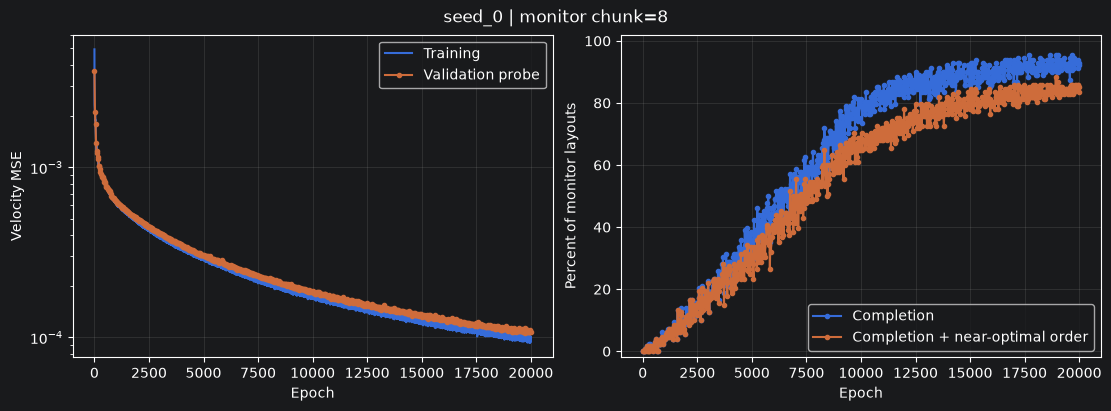

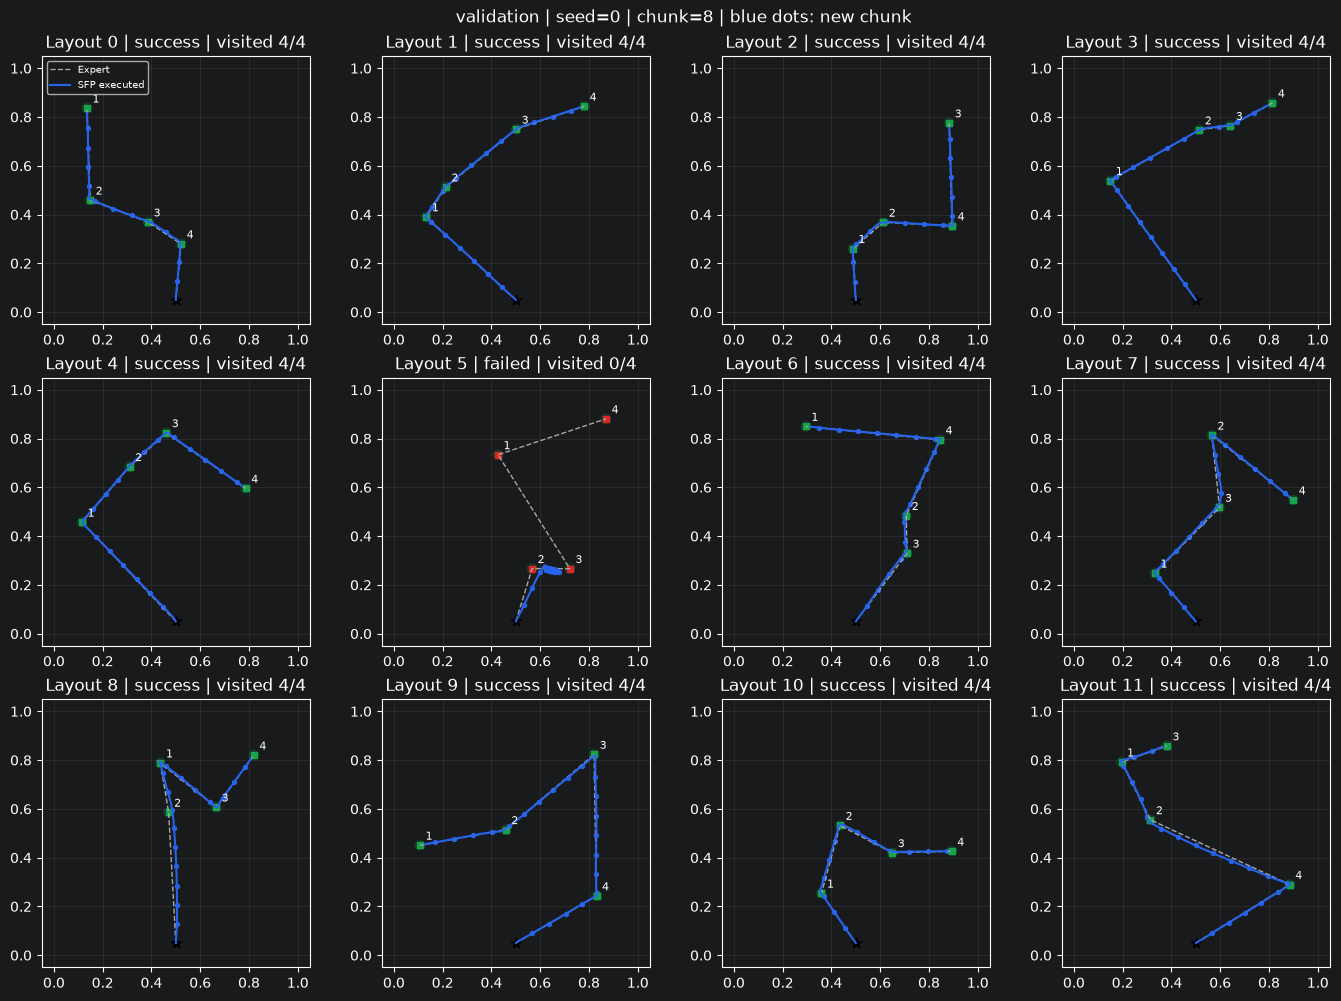

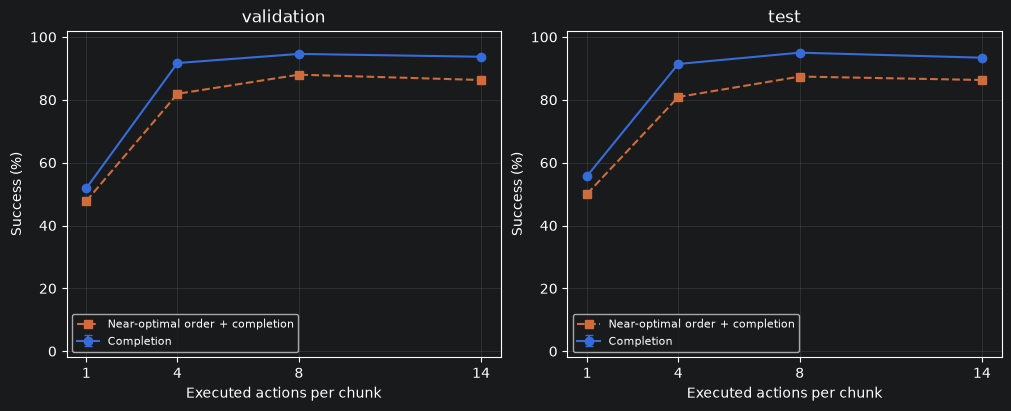

Final metrics: /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5


In [40]:
def final_evaluation():
    all_rows, summary_rows, paired_rows = [], [], []
    for seed in SEEDS:
        run_dir = RUN_ROOT / f"seed_{seed}"
        checkpoint = own_checkpoint_load(run_dir / "best.pt")
        if checkpoint["run_id"] != RUN_ID:
            raise RuntimeError("Unexpected checkpoint run ID.")
        model = VelocityMLP().to(device)
        model.load_state_dict(checkpoint["model"])
        selected_epoch = checkpoint["epoch"]
        print(f"Evaluating seed={seed}, validation-selected checkpoint epoch={selected_epoch}")
        seed_rows = []
        for split_name in ("validation", "test"):
            by_chunk = {}
            for chunk in EVAL["chunks"]:
                rows = evaluate(model, splits[split_name], split_name, seed, chunk, selected_epoch)
                by_chunk[chunk] = rows
                seed_rows.extend(rows)
                summary = summarize(rows)
                summary_rows.append(dict(seed=seed, split=split_name, chunk=chunk,
                                         epoch=selected_epoch, gap_bin="ALL", **summary))
                for label in ("<1%", "1-<5%", "5-<10%", ">=10%"):
                    group = [r for r in rows if r["gap_bin"] == label]
                    if group:
                        summary_rows.append(dict(seed=seed, split=split_name, chunk=chunk,
                                                 epoch=selected_epoch, gap_bin=label, **summarize(group)))
                print(f"  {split_name:10s} chunk={chunk:2d}: complete={summary['success_percent']:6.2f}% | "
                      f"optimal order={summary['optimal_order_success_percent']:6.2f}% | "
                      f"near-opt order={summary['nearopt_order_success_percent']:6.2f}% | "
                      f"mean visits={summary['mean_visited']:.3f}", flush=True)
            primary = by_chunk[EVAL["primary_chunk"]]
            for chunk in EVAL["chunks"]:
                if chunk == EVAL["primary_chunk"]:
                    continue
                current = by_chunk[chunk]
                rescued = sum(r["success"] and not p["success"] for r, p in zip(current, primary))
                regressed = sum(p["success"] and not r["success"] for r, p in zip(current, primary))
                paired_rows.append(dict(seed=seed, split=split_name, chunk=chunk,
                                        reference_chunk=EVAL["primary_chunk"],
                                        n_layouts=len(current), rescued=rescued, regressed=regressed,
                                        success_difference_pp=100*(rescued-regressed)/len(current)))
        write_csv(run_dir / "per_layout.csv", seed_rows)
        all_rows.extend(seed_rows)
        plot_training(run_dir)
        plot_examples(model, splits["validation"], seed, "validation", EVAL["primary_chunk"], run_dir)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    write_csv(RUN_ROOT / "per_layout.csv", all_rows)
    write_csv(RUN_ROOT / "per_seed_summary.csv", summary_rows)
    write_csv(RUN_ROOT / "paired_chunk_changes.csv", paired_rows)
    across = []
    groups = sorted({(r["split"], r["chunk"], r["gap_bin"]) for r in summary_rows})
    for split_name, chunk, label in groups:
        group = [r for r in summary_rows if (r["split"], r["chunk"], r["gap_bin"]) == (split_name, chunk, label)]
        row = dict(split=split_name, chunk=chunk, gap_bin=label, n_seeds=len(group))
        for key in ("success_percent", "nearopt_order_success_percent", "optimal_order_success_percent", "mean_visited"):
            values = np.array([r[key] for r in group])
            row["mean_" + key] = values.mean()
            row["seed_sd_" + key] = values.std(ddof=1) if len(values) > 1 else float("nan")
        across.append(row)
    write_csv(RUN_ROOT / "across_seed_summary.csv", across)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    for ax, split_name in zip(axes, ("validation", "test")):
        group = sorted([r for r in across if r["split"] == split_name and r["gap_bin"] == "ALL"],
                       key=lambda r: r["chunk"])
        xs = [r["chunk"] for r in group]
        ys = [r["mean_success_percent"] for r in group]
        err = [0 if math.isnan(r["seed_sd_success_percent"]) else r["seed_sd_success_percent"] for r in group]
        ax.errorbar(xs, ys, yerr=err, fmt="o-", capsize=3, label="Completion")
        ax.plot(xs, [r["mean_nearopt_order_success_percent"] for r in group], "s--", label="Near-optimal order + completion")
        ax.set(xlabel="Executed actions per chunk", ylabel="Success (%)", title=split_name,
               xticks=xs, ylim=(-2, 102))
        ax.grid(alpha=.2); ax.legend(fontsize=8)
    fig.savefig(RUN_ROOT / "chunk_comparison.png", dpi=160)
    plt.show(); plt.close(fig)
    print("Final metrics:", RUN_ROOT)
    return all_rows, summary_rows


all_metrics, summaries = final_evaluation()


## 14. 打包结果

运行后，把最后打印的 `results_to_share.zip` 发回来即可。里面包含配置、逐布局结果、各 seed 汇总、chunk 对比图、训练曲线和少量示例轨迹，不包含大模型权重或完整训练数据。

这版回答的是“滑窗闭环结构能否改善四箱任务”。没有加入随机初始位置、多模态近最优示范或恢复数据；这些可以在拿到清楚的基线后分别研究。

In [27]:
metric_notes = """Streaming four-target experiment v1

Policy: state-trajectory SFP with measured xy, four fixed box coordinates and
observed visited bits in the last observation frames. No planner or order selector
is used at inference. The ideal kinematic environment follows the commanded segment.
Each new action is executed immediately. Conditions are frozen within a chunk;
at its boundary the history is updated and local flow time resets to zero.

Window convention: pred_horizon counts history frames plus future frames.
With 2 observation frames and 16 total frames there are 14 future intervals.
Local xi(0) is current position and xi(1) is 14 control steps into the future.
Default chunk 8 only integrates to 8/14 before the next observation update.
Gaussian training tube: sigma(t)=sigma0*exp(-k*t). Inference noise is zero.

Expert routes minimize Euclidean length through all four box CENTERS (open tour).
Box centers are included explicitly during discretization. At evaluation, a box
is visited when the realized continuous segment enters its visit-tolerance circle.
Episode termination trims the last executed segment at first full completion.

completion: all four boxes reached within max_env_steps and no invalid prediction.
optimal_order_success: completion AND first-visit center-order length equals
the exact center optimum (relative tolerance 1e-6, accepting tied optima).
nearopt_order_success: completion AND center-order gap <= nearopt_slack.
Neither order metric claims the executed curve is shortest.
length_to_center_optimal: executed length / center-based optimum, on successes.
It MAY BE BELOW ONE because touching a tolerance circle need not reach its center.
It is a reference-relative length, NOT an exact optimality gap for disk visitation.
Failed rollouts are not included in success-only length averages; always read these
alongside completion rate and the per-layout records.

Best checkpoint: highest completion on a fixed validation monitor subset, then
near-optimal order success, mean visits, and lower velocity MSE. The primary chunk
alone selects the checkpoint. Every final chunk uses that same checkpoint.
Test results do not select checkpoints. Changing chunk alters feedback frequency
but not the number of actions allowed or the numerical integrator.
The old full-episode model is not retrained here. Chunk=14 is a full LOCAL-window
baseline, NOT the old full-four-boxes-in-one-flow experiment.

There is no recovery-data augmentation, latent mode variable, or multimodal
near-optimal training in this first-stage experiment. Completion or global
optimality is not guaranteed. A pipeline smoke run is not a learning result.
Exact continuation is intended on the same software/device; different hardware
can cause floating-point differences. Moving the whole output folder is supported.
"""
(RUN_ROOT / "metric_notes.txt").write_text(metric_notes, encoding="utf-8")
atomic_json(RUN_ROOT / "evaluation_record.json", dict(
    requested_epochs=EPOCHS, seeds=SEEDS, primary_chunk=EVAL["primary_chunk"],
    evaluated_chunks=EVAL["chunks"], run_id=RUN_ID, quick_check=QUICK_CHECK))
archive = RUN_ROOT / "results_to_share.zip"
# Save metrics, figures and small example paths. Exclude data and model weights.
with zipfile.ZipFile(archive, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for path in sorted(RUN_ROOT.iterdir()):
        if path.is_file() and path.suffix in (".csv", ".json", ".txt", ".png"):
            z.write(path, path.relative_to(RUN_ROOT))
    for seed in SEEDS:
        for path in sorted((RUN_ROOT / f"seed_{seed}").iterdir()):
            if path.is_file() and path.suffix in (".csv", ".json", ".png", ".npz"):
                z.write(path, path.relative_to(RUN_ROOT))
print("Ready to share:", archive)


Ready to share: /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/results_to_share.zip


Chunk sweep: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Checkpoint: best.pt
Validation layouts: 1000
Output: /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best

Seed 0 | checkpoint=best.pt | epoch=9700
  chunk= 1 | complete= 17.00% | optimal order= 11.00% | near-opt order= 12.70% | mean visits=1.429 | length ratio=1.1627
  chunk= 2 | complete= 47.10% | optimal order= 34.60% | near-opt order= 38.10% | mean visits=2.376 | length ratio=1.0821
  chunk= 3 | complete= 64.80% | optimal order= 47.90% | near-opt order= 54.00% | mean visits=2.888 | length ratio=1.0579
  chunk= 4 | complete= 75.40% | optimal order= 56.70% | near-opt order= 64.40% | mean visits=3.225 | length ratio=1.0445
  chunk= 5 | complete= 79.20% | optimal order= 59.70% | near-opt order= 68.40% | mean visits=3.355 | length ratio=1.0308
  chunk= 6 | complete= 79.60% | optimal order= 61.00% | near-opt order= 69.

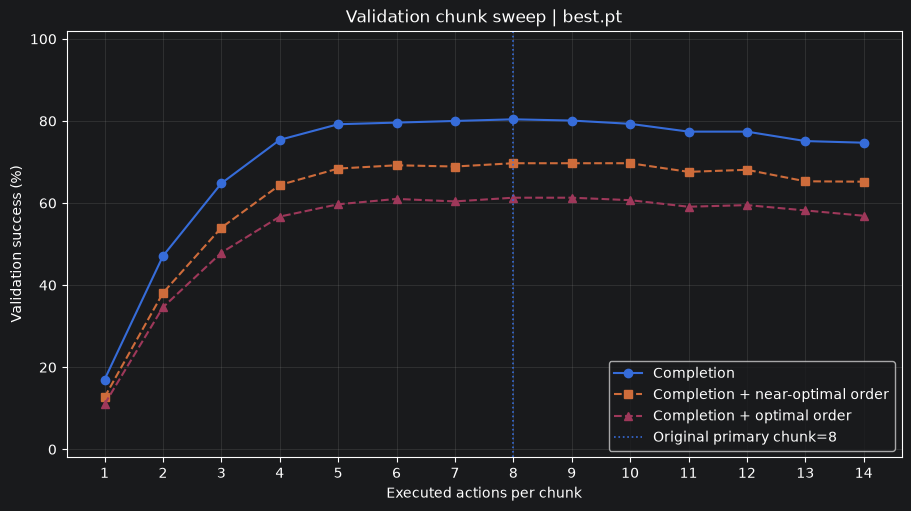

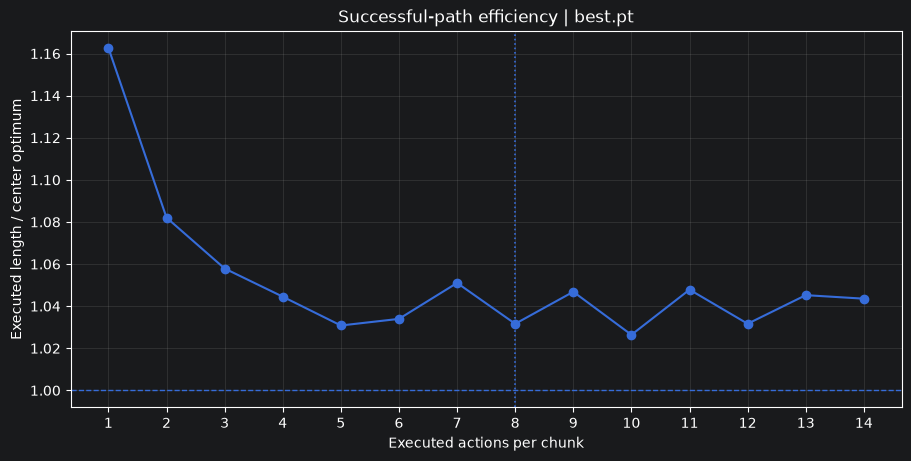


Saved:
  /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best/chunk_sweep_per_seed.csv
  /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best/chunk_sweep_across_seeds.csv
  /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best/chunk_sweep_per_layout.csv
  /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best/chunk_sweep_success.png
  /home/u7779895/PycharmProjects/streaming-flow-policy/experiments/four_boxes_experiments/sfp_four_targets_streaming_v1/runs/ef96247d20f5/chunk_sweep_validation_best/chunk_sweep_length_ratio.png


In [28]:
# ============================================================
# Validation-only chunk sweep: chunk = 1, 2, ..., 14
#
# IMPORTANT:
# - No training.
# - Does not modify the original EVAL["chunks"].
# - Does not touch the test set.
# - Uses the existing trained checkpoint.
# ============================================================

CHUNK_SWEEP = list(range(1, FUTURE_STEPS + 1))

# "best.pt" is the checkpoint selected by the original primary chunk=8.
# Keep this first so that the result is directly comparable with the
# existing experiment.
#
# Later, if training finished normally, you may change this to:
# CHECKPOINT_NAME = "latest.pt"
# for a useful sensitivity check that is not selected by chunk=8 performance.
CHECKPOINT_NAME = "best.pt"

SWEEP_DIR = RUN_ROOT / f"chunk_sweep_validation_{Path(CHECKPOINT_NAME).stem}"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

print("Chunk sweep:", CHUNK_SWEEP)
print("Checkpoint:", CHECKPOINT_NAME)
print("Validation layouts:", len(splits["validation"]["targets"]))
print("Output:", SWEEP_DIR)
print()

summary_rows = []
per_layout_rows = []

for seed in SEEDS:
    run_dir = RUN_ROOT / f"seed_{seed}"
    checkpoint_path = run_dir / CHECKPOINT_NAME

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing checkpoint for seed {seed}: {checkpoint_path}"
        )

    checkpoint = own_checkpoint_load(checkpoint_path)

    if checkpoint.get("run_id") != RUN_ID:
        raise RuntimeError(
            f"Checkpoint run ID mismatch for seed {seed}."
        )

    selected_epoch = int(checkpoint["epoch"])

    model = VelocityMLP().to(device)
    model.load_state_dict(checkpoint["model"], strict=True)
    model.eval()

    print(
        f"Seed {seed} | checkpoint={CHECKPOINT_NAME} "
        f"| epoch={selected_epoch}"
    )

    for chunk in CHUNK_SWEEP:
        rows = evaluate(
            model=model,
            split=splits["validation"],
            split_name="validation_chunk_sweep",
            seed=seed,
            chunk=chunk,
            epoch=selected_epoch,
        )

        summary = summarize(rows)

        summary_row = dict(
            seed=seed,
            checkpoint=CHECKPOINT_NAME,
            checkpoint_epoch=selected_epoch,
            chunk=chunk,
            **summary,
        )

        summary_rows.append(summary_row)
        per_layout_rows.extend(rows)

        print(
            f"  chunk={chunk:2d} | "
            f"complete={summary['success_percent']:6.2f}% | "
            f"optimal order={summary['optimal_order_success_percent']:6.2f}% | "
            f"near-opt order={summary['nearopt_order_success_percent']:6.2f}% | "
            f"mean visits={summary['mean_visited']:.3f} | "
            f"length ratio={summary['mean_length_to_center_optimal_success']:.4f}"
        )

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

# ------------------------------------------------------------
# Save raw results
# ------------------------------------------------------------

write_csv(SWEEP_DIR / "chunk_sweep_per_seed.csv", summary_rows)
write_csv(SWEEP_DIR / "chunk_sweep_per_layout.csv", per_layout_rows)

# ------------------------------------------------------------
# Aggregate across training seeds
# ------------------------------------------------------------

METRICS = [
    "success_percent",
    "optimal_order_success_percent",
    "nearopt_order_success_percent",
    "mean_visited",
    "mean_actual_length_success",
    "mean_length_to_center_optimal_success",
]

aggregate_rows = []

for chunk in CHUNK_SWEEP:
    group = [r for r in summary_rows if r["chunk"] == chunk]

    row = dict(
        checkpoint=CHECKPOINT_NAME,
        chunk=chunk,
        n_seeds=len(group),
    )

    for key in METRICS:
        values = np.asarray([float(r[key]) for r in group], dtype=np.float64)

        row["mean_" + key] = float(np.nanmean(values))

        valid = values[np.isfinite(values)]
        row["sd_" + key] = (
            float(np.std(valid, ddof=1))
            if len(valid) > 1
            else float("nan")
        )

    aggregate_rows.append(row)

write_csv(SWEEP_DIR / "chunk_sweep_across_seeds.csv", aggregate_rows)

# ------------------------------------------------------------
# Print ranking
# Primary ranking:
#   1. completion
#   2. near-optimal-order completion
#   3. optimal-order completion
# ------------------------------------------------------------

ranked = sorted(
    aggregate_rows,
    key=lambda r: (
        r["mean_success_percent"],
        r["mean_nearopt_order_success_percent"],
        r["mean_optimal_order_success_percent"],
    ),
    reverse=True,
)

print("\n=== Validation chunk ranking ===")

for rank, r in enumerate(ranked, start=1):
    print(
        f"{rank:2d}. chunk={r['chunk']:2d} | "
        f"complete={r['mean_success_percent']:6.2f}% | "
        f"near-opt={r['mean_nearopt_order_success_percent']:6.2f}% | "
        f"optimal={r['mean_optimal_order_success_percent']:6.2f}% | "
        f"mean visits={r['mean_mean_visited']:.3f}"
    )

# ------------------------------------------------------------
# Plot 1: task performance versus chunk size
# ------------------------------------------------------------

chunks = np.asarray(
    [r["chunk"] for r in aggregate_rows],
    dtype=np.int64,
)

completion = np.asarray(
    [r["mean_success_percent"] for r in aggregate_rows],
    dtype=np.float64,
)

nearopt = np.asarray(
    [r["mean_nearopt_order_success_percent"] for r in aggregate_rows],
    dtype=np.float64,
)

optimal = np.asarray(
    [r["mean_optimal_order_success_percent"] for r in aggregate_rows],
    dtype=np.float64,
)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

ax.plot(chunks, completion, "o-", label="Completion")
ax.plot(chunks, nearopt, "s--", label="Completion + near-optimal order")
ax.plot(chunks, optimal, "^--", label="Completion + optimal order")

ax.axvline(
    EVAL["primary_chunk"],
    linestyle=":",
    linewidth=1.2,
    label=f"Original primary chunk={EVAL['primary_chunk']}",
)

ax.set(
    xlabel="Executed actions per chunk",
    ylabel="Validation success (%)",
    title=f"Validation chunk sweep | {CHECKPOINT_NAME}",
    xticks=CHUNK_SWEEP,
    ylim=(-2, 102),
)

ax.grid(alpha=0.2)
ax.legend()

fig.savefig(
    SWEEP_DIR / "chunk_sweep_success.png",
    dpi=180,
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------
# Plot 2: path efficiency among successful rollouts
# ------------------------------------------------------------

length_ratio = np.asarray(
    [
        r["mean_mean_length_to_center_optimal_success"]
        for r in aggregate_rows
    ],
    dtype=np.float64,
)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)

ax.plot(chunks, length_ratio, "o-")

ax.axvline(
    EVAL["primary_chunk"],
    linestyle=":",
    linewidth=1.2,
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set(
    xlabel="Executed actions per chunk",
    ylabel="Executed length / center optimum",
    title=f"Successful-path efficiency | {CHECKPOINT_NAME}",
    xticks=CHUNK_SWEEP,
)

ax.grid(alpha=0.2)

fig.savefig(
    SWEEP_DIR / "chunk_sweep_length_ratio.png",
    dpi=180,
)

plt.show()
plt.close(fig)

print("\nSaved:")
print(" ", SWEEP_DIR / "chunk_sweep_per_seed.csv")
print(" ", SWEEP_DIR / "chunk_sweep_across_seeds.csv")
print(" ", SWEEP_DIR / "chunk_sweep_per_layout.csv")
print(" ", SWEEP_DIR / "chunk_sweep_success.png")
print(" ", SWEEP_DIR / "chunk_sweep_length_ratio.png")